# Bank Loan Approval Prediction Project

### Damil Randhawa



## Project Overview
The goal of this project is to predict whether a loan will be approved (loan_status = 1) or not approved/defaulted (loan_status = 0). We'll analyze key factors such as credit score, income, loan amount, and demographic information to build machine learning models that can predict loan outcomes.

## Dataset Information
**Source:** Kaggle - Bank Loan Data  
**Size**: 45,000 loan applications  
**Features**: 14 columns including demographics, financial info, and credit history  
**Currency**: US Dollars ($)

**Project Workflow** 
- Data Loading & Exploration - Understanding dataset structure
- Data Cleaning - Handling missing values and data quality
- Exploratory Data Analysis (EDA) - Visualizing patterns 
- Data Processing- Encoding and feature engineering
- Model Building - Training ML models
- Model Evaluation - Performance comparison
- Conclusion** - Key insights and recommendations

---
## 1. Import Libraries

In [65]:
# Import required libraries
import numpy as np           
import pandas as pd          
import matplotlib.pyplot as plt  # visualizations
import seaborn as sns        #  data visualization
import warnings              #  warning messages

# Configure display settings
warnings.filterwarnings('ignore')  
pd.set_option('display.max_columns', None)  # Display all columns in dataframes
sns.set_style('whitegrid')  # set seaborn plot style with grid background
sns.set_palette('husl')     # set color palette for consistent, appealing colors
%matplotlib inline        

print(" Libraries imported successfully!")

 Libraries imported successfully!


---
## 2. Load Dataset

In [66]:
# Load the dataset
data = pd.read_csv('loan_data.csv')

print(f"\nDataset Shape: {data.shape[0]:,} rows × {data.shape[1]} columns")


Dataset Shape: 45,000 rows × 14 columns


In [67]:
# Display first 10 rows
print("First 10 rows of the dataset:\n")
data.head(10)

First 10 rows of the dataset:



,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1


In [68]:
# Display last 5 rows
print("Last 5 rows of the dataset:\n")
data.tail()

Last 5 rows of the dataset:



,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1
44999,24.0,male,High School,51609.0,1,RENT,6665.0,DEBTCONSOLIDATION,17.05,0.13,3.0,628,No,1


In [69]:
# Dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [70]:
# Display all column names
print("Column Names:")
for i, col in enumerate(data.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. person_age
 2. person_gender
 3. person_education
 4. person_income
 5. person_emp_exp
 6. person_home_ownership
 7. loan_amnt
 8. loan_intent
 9. loan_int_rate
10. loan_percent_income
11. cb_person_cred_hist_length
12. credit_score
13. previous_loan_defaults_on_file
14. loan_status


In [71]:
# Statistical summary
print("Statistical Summary:\n")
data.describe()

Statistical Summary:



,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [72]:
# Separate numerical and categorical columns
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"  - {col}")

print(f"\nCategorical columns ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Numerical columns (9):
  - person_age
  - person_income
  - person_emp_exp
  - loan_amnt
  - loan_int_rate
  - loan_percent_income
  - cb_person_cred_hist_length
  - credit_score
  - loan_status

Categorical columns (5):
  - person_gender
  - person_education
  - person_home_ownership
  - loan_intent
  - previous_loan_defaults_on_file


---
## 3. Data Cleaning

In [73]:
# Check for missing values
print("Missing Values Analysis:")

missing_data = pd.DataFrame({
    'Column': data.columns,
    'Missing_Count': data.isnull().sum().values,
    'Missing_%': (data.isnull().sum() / len(data) * 100).round(2).values
})

missing_data = missing_data[missing_data['Missing_Count'] > 0]

if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print(" No missing values found!")

Missing Values Analysis:
 No missing values found!


In [74]:
# Check for duplicate rows
duplicate_count = data.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count > 0:
    print(f" Found {duplicate_count:,} duplicates")
else:
    print("No duplicate rows found!")

Duplicate rows: 0
No duplicate rows found!


In [75]:
# Analyze target variable
print("Target Variable Analysis (loan_status):")
print()
print("Value Counts:")
print(data['loan_status'].value_counts())

print("\nPercentage Distribution:")
percentage_dist = data['loan_status'].value_counts(normalize=True).mul(100).round(2)
print(percentage_dist)

print("\nInterpretation:")
print("  0 = Not Approved")
print("  1 = Approved")

# Show percentages in clearer format
approved_pct = (data['loan_status'] == 1).sum() / len(data) * 100
not_approved_pct = (data['loan_status'] == 0).sum() / len(data) * 100

print(f" Approved: {approved_pct:.2f}% ({(data['loan_status'] == 1).sum():,} loans)")
print(f"Not Approved: {not_approved_pct:.2f}% ({(data['loan_status'] == 0).sum():,} loans)")

Target Variable Analysis (loan_status):

Value Counts:
0    35000
1    10000
Name: loan_status, dtype: int64

Percentage Distribution:
0    77.78
1    22.22
Name: loan_status, dtype: float64

Interpretation:
  0 = Not Approved
  1 = Approved
 Approved: 22.22% (10,000 loans)
Not Approved: 77.78% (35,000 loans)


In [76]:
# Analyze categorical variables
print("Categorical Variables Distribution:")

for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts())
    print(f"  Total unique values: {data[col].nunique()}")

Categorical Variables Distribution:

person_gender:
male      24841
female    20159
Name: person_gender, dtype: int64
  Total unique values: 2

person_education:
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: person_education, dtype: int64
  Total unique values: 5

person_home_ownership:
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: person_home_ownership, dtype: int64
  Total unique values: 4

loan_intent:
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: loan_intent, dtype: int64
  Total unique values: 6

previous_loan_defaults_on_file:
Yes    22858
No     22142
Name: previous_loan_defaults_on_file, dtype: int64
  Total unique values: 2


## 4. Exploratory Data Analysis (EDA)

In [77]:
approval_colors = {0: '#E74C3C', 1: '#2ECC71'}

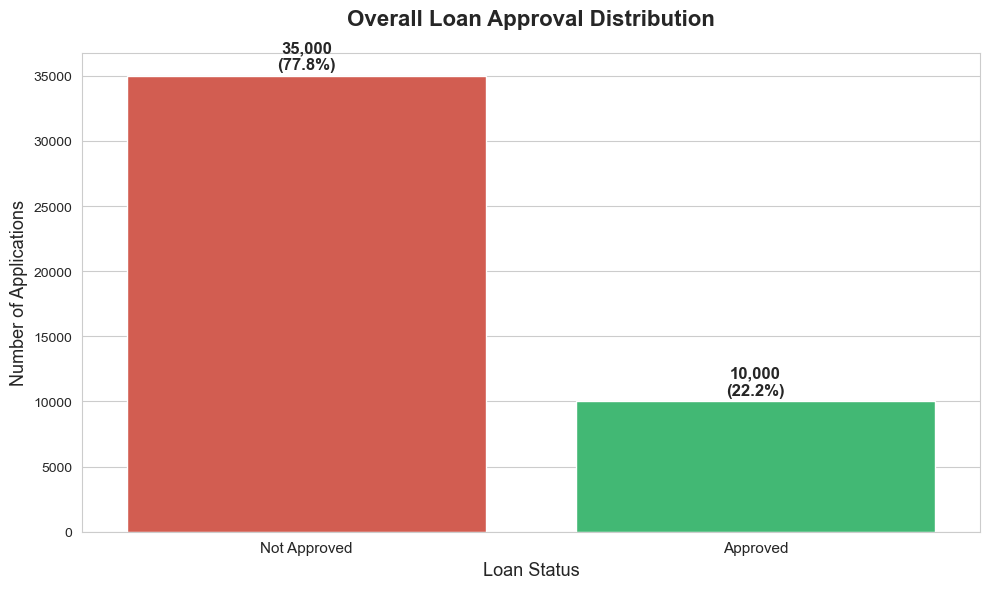

In [78]:
plt.figure(figsize=(10, 6))

# Create count plot
ax = sns.countplot(data=data, x='loan_status', palette=approval_colors)

# Add count and percentage labels
total = len(data)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height/total:.1f}%'
    ax.text(p.get_x() + p.get_width()/2., height + 500,
            f'{int(height):,}\n({percentage})',
            ha='center', fontsize=12, fontweight='bold')

plt.title('Overall Loan Approval Distribution', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Loan Status', fontsize=13)
plt.ylabel('Number of Applications', fontsize=13)
plt.xticks([0, 1], ['Not Approved', 'Approved'], fontsize=11)
plt.tight_layout()
plt.show()


The dataset is highly imbalanced. Out of 45,000 total loan applications, 77.8% (35,000) were not approved, while only 22.2% (10,000) were approved. This shows a strong skew toward loan denials. This imbalance is important because it affects both the fairness analysis and the performance of any machine-learning model trained on the data. Models may naturally learn to predict “Not Approved” more often unless the imbalance is addressed.

2. Gender Bias Analysis

Question: Are men and women approved at similar rates?


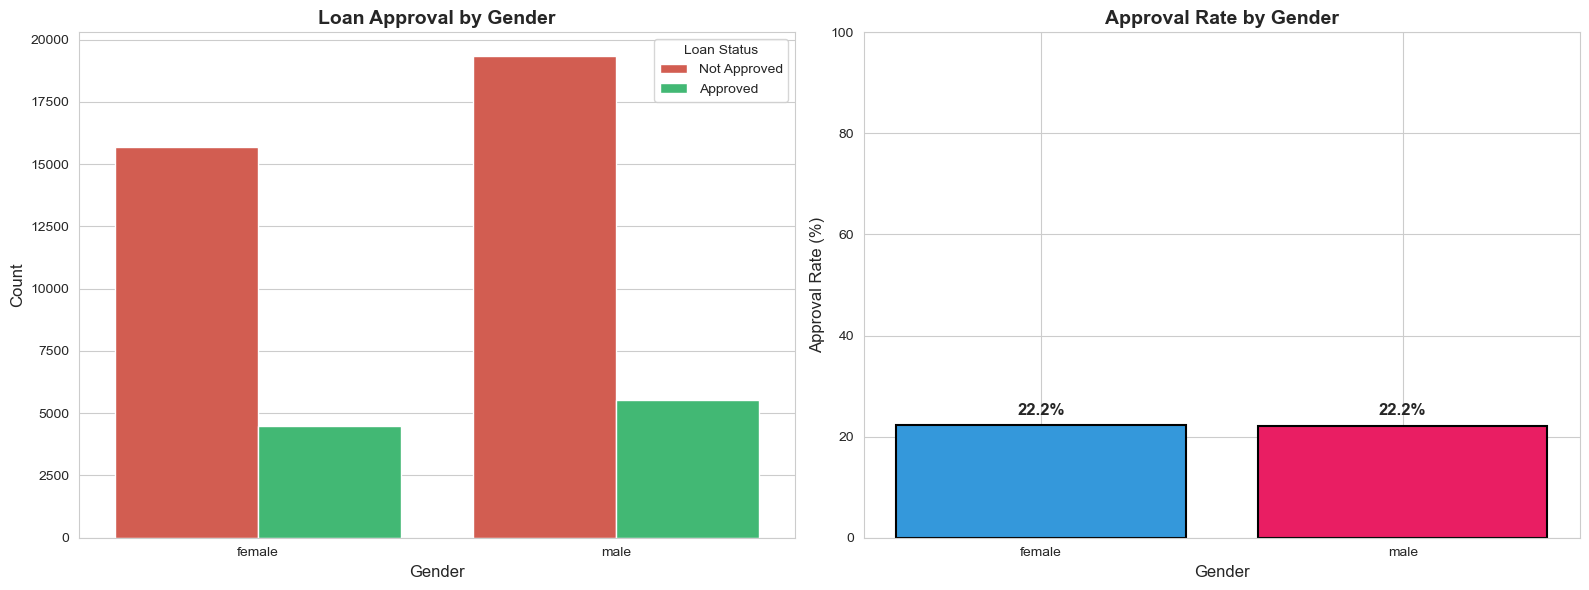

In [79]:
print("2. Gender Bias Analysis")
print("\nQuestion: Are men and women approved at similar rates?")
ig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Count plot
sns.countplot(data=data, x='person_gender', hue='loan_status', 
              palette=approval_colors, ax=axes[0])
axes[0].set_title('Loan Approval by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Loan Status', labels=['Not Approved', 'Approved'])

# Right: Approval rate
gender_approval = data.groupby('person_gender')['loan_status'].mean() * 100
bars = axes[1].bar(gender_approval.index, gender_approval.values, 
                   color=['#3498DB', '#E91E63'], edgecolor='black', linewidth=1.5)
axes[1].set_title('Approval Rate by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Approval Rate (%)', fontsize=12)
axes[1].set_ylim(0, 100)

# Add percentage labels
for bar, rate in zip(bars, gender_approval.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

Loan Approval by Gender

Both men and women have similar patterns in approval versus denial numbers. The volume of applicants differs slightly (more males than females), but the distribution of approved and not approved loans appears proportionally similar.

Approval Rate by Gender

Approval rates for both genders are almost identical:

Female: 22.2%

Male: 22.2%

This suggests no evidence of gender bias in the approval process. The model or lending criteria appear to treat male and female applicants equally in this dataset.

3. Education Level Inequality Analysis

Question: Do people with higher education get approved more often?


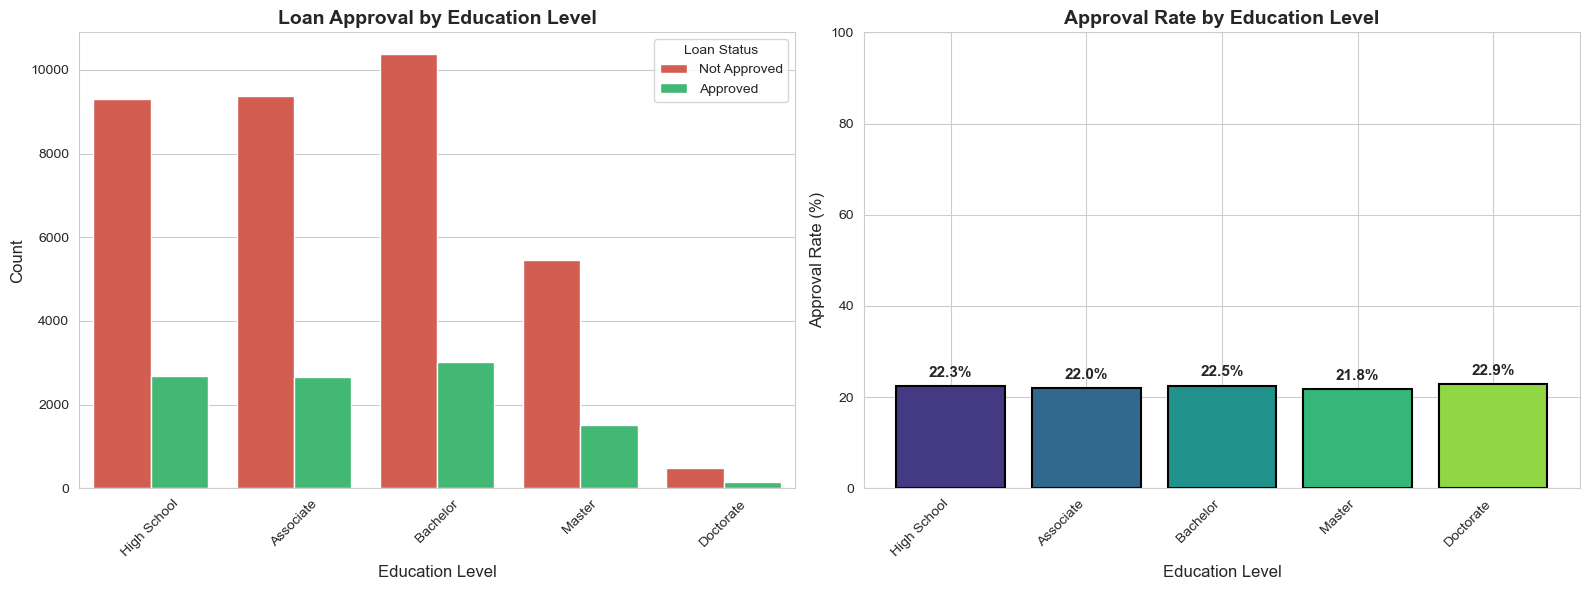

In [80]:
print("3. Education Level Inequality Analysis")
print("\nQuestion: Do people with higher education get approved more often?")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Count plot
education_order = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']
sns.countplot(data=data, x='person_education', hue='loan_status',
              order=education_order, palette=approval_colors, ax=axes[0])
axes[0].set_title('Loan Approval by Education Level', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Education Level', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Loan Status', labels=['Not Approved', 'Approved'])
axes[0].tick_params(axis='x', rotation=45)

# Right: Approval rate
edu_approval = data.groupby('person_education')['loan_status'].mean() * 100
edu_approval = edu_approval.reindex(education_order)
bars = axes[1].bar(range(len(edu_approval)), edu_approval.values,
                   color=sns.color_palette('viridis', len(edu_approval)), 
                   edgecolor='black', linewidth=1.5)
axes[1].set_title('Approval Rate by Education Level', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Education Level', fontsize=12)
axes[1].set_ylabel('Approval Rate (%)', fontsize=12)
axes[1].set_xticks(range(len(edu_approval)))
axes[1].set_xticklabels(edu_approval.index, rotation=45, ha='right')
axes[1].set_ylim(0, 100)

# Add percentage labels
for bar, rate in zip(bars, edu_approval.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Different education levels have different volumes of applicants, but across all groups, the number of “Not Approved” applications is much higher than approved ones. For example:

Bachelor’s and Associate degrees have high application volumes.

Doctorate applicants are few, but still mostly denied.

Approval Rate by Education Level

Approval rates are very similar across all education levels:

High School: 22.3%

Associate: 22.0%

Bachelor: 22.5%

Master: 21.8%

Doctorate: 22.9%

These values fluctuate only slightly around 22%, indicating education level does not significantly impact loan approval probability in this dataset.

4. Home Ownership Inequality

Question: Does owning property make you more likely to get approved?


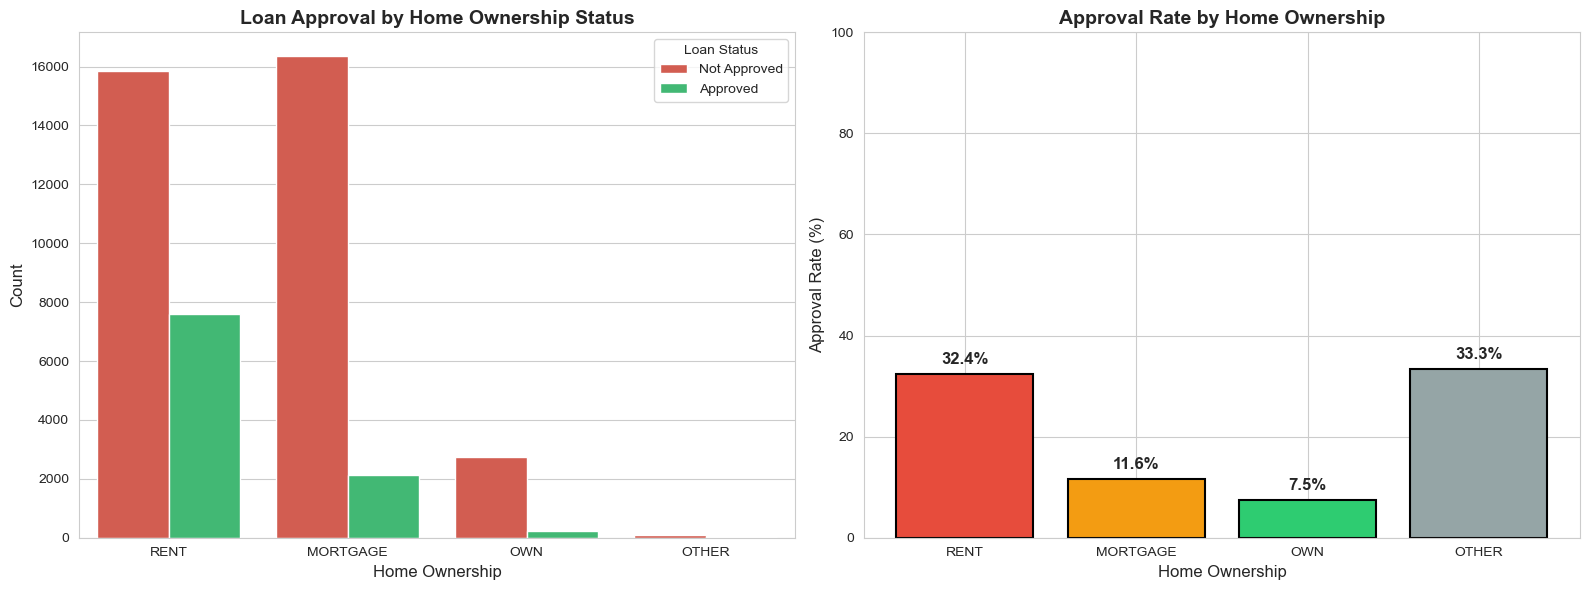

In [81]:
print("4. Home Ownership Inequality")
print("\nQuestion: Does owning property make you more likely to get approved?")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Count plot
home_order = ['RENT', 'MORTGAGE', 'OWN', 'OTHER']
sns.countplot(data=data, x='person_home_ownership', hue='loan_status',
              order=home_order, palette=approval_colors, ax=axes[0])
axes[0].set_title('Loan Approval by Home Ownership Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Home Ownership', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].legend(title='Loan Status', labels=['Not Approved', 'Approved'])

# Right: Approval rate
home_approval = data.groupby('person_home_ownership')['loan_status'].mean() * 100
home_approval = home_approval.reindex(home_order)
bars = axes[1].bar(range(len(home_approval)), home_approval.values,
                   color=['#E74C3C', '#F39C12', '#2ECC71', '#95A5A6'],
                   edgecolor='black', linewidth=1.5)
axes[1].set_title('Approval Rate by Home Ownership', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Home Ownership', fontsize=12)
axes[1].set_ylabel('Approval Rate (%)', fontsize=12)
axes[1].set_xticks(range(len(home_approval)))
axes[1].set_xticklabels(home_approval.index)
axes[1].set_ylim(0, 100)

# Add percentage labels
for bar, rate in zip(bars, home_approval.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 2,
                f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Applicants with RENT or MORTGAGE status dominate the dataset. Those who OWN their home are a much smaller group.

Approval Rates by Home Ownership

Approval rates differ more noticeably here:

Rent: 32.4%

Mortgage: 11.6%

Own: 7.5%

Other: 33.3%

This suggests:

- Renters and individuals classified as “Other” actually have higher approval rates.
- Those with mortgages or full ownership have lower approval rates.
- This pattern goes against typical financial expectations, where ownership often signals stability. This could indicate dataset-specific rules, biases, or missing contextual variables.

5. Loan Intent Analysis

Question: Are certain loan purposes approved more than others?


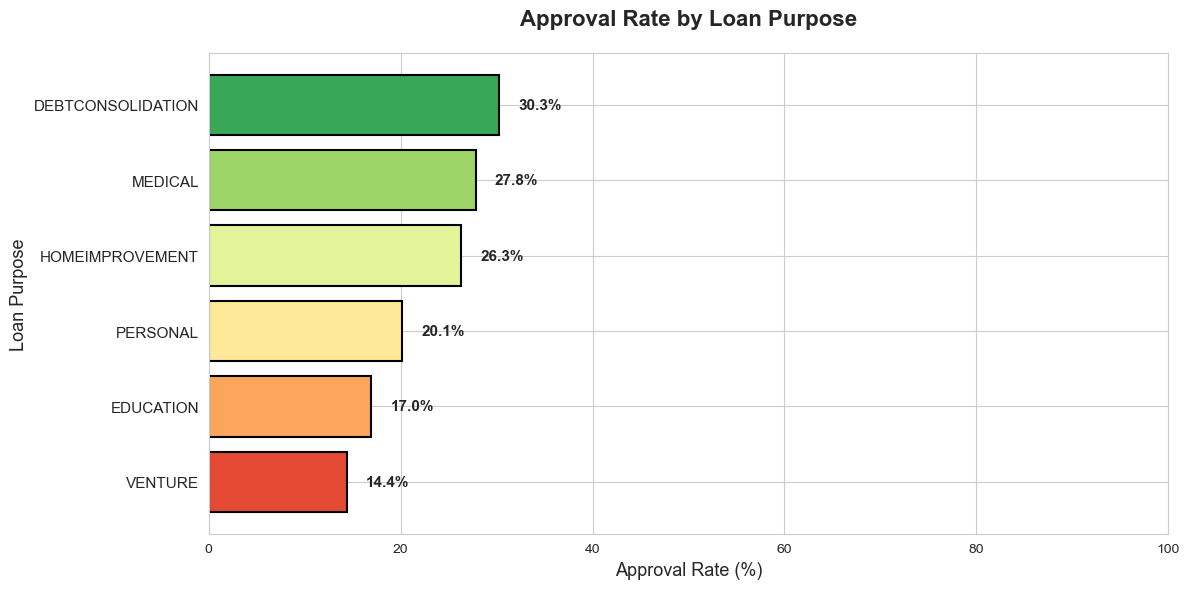

In [82]:
print("5. Loan Intent Analysis")
print("\nQuestion: Are certain loan purposes approved more than others?")

# Calculate approval rates
intent_approval = data.groupby('loan_intent')['loan_status'].agg(['mean', 'count', 'sum'])
intent_approval['approval_rate'] = intent_approval['mean'] * 100
intent_approval = intent_approval.sort_values('approval_rate', ascending=True)

# Create horizontal bar chart
plt.figure(figsize=(12, 6))

bars = plt.barh(range(len(intent_approval)), intent_approval['approval_rate'],
                color=sns.color_palette('RdYlGn', len(intent_approval)),
                edgecolor='black', linewidth=1.5)

plt.title('Approval Rate by Loan Purpose', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Approval Rate (%)', fontsize=13)
plt.ylabel('Loan Purpose', fontsize=13)
plt.yticks(range(len(intent_approval)), intent_approval.index, fontsize=11)
plt.xlim(0, 100)

# Add percentage labels
for i, (bar, rate) in enumerate(zip(bars, intent_approval['approval_rate'])):
    width = bar.get_width()
    plt.text(width + 2, bar.get_y() + bar.get_height()/2.,
            f'{rate:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Certain loan purposes have notably higher approval rates than others:

Debt Consolidation: 30.3%

Medical: 27.8%

Home Improvement: 26.3%

Personal: 20.1%

Education: 17.0%

Venture: 14.4%

The highest approval rates are associated with debt consolidation, medical, and home improvement loans. These categories likely represent lower-risk lending situations. In contrast, education and venture loans have much lower approval rates, suggesting these intents carry higher risk from a lender’s perspective.

Overall, loan intent plays a meaningful role in approval likelihood.

## Data Processing

In [83]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

I will  convert categorical variables like male/female' into numbers like 1/0.

In [84]:
# Create a copy of the data to preserve the original
data_encoded = data.copy()

# Initialize label encoder
label_encoder = LabelEncoder()

# List of categorical columns to encode
categorical_columns = [
    'person_gender',
    'person_education', 
    'person_home_ownership',
    'loan_intent',
    'previous_loan_defaults_on_file'
]

print(f"\nEncoding {len(categorical_columns)} categorical columns...\n")

# Encode each categorical column
for column in categorical_columns:
    # Store original values for reference
    original_values = data_encoded[column].unique()
    
    # Encode the column (convert text to numbers)
    data_encoded[column] = label_encoder.fit_transform(data_encoded[column])
    
    # Show the mapping
    encoded_values = data_encoded[column].unique()
    print(f"{column}:")
    for orig, enc in zip(sorted(original_values), sorted(encoded_values)):
        print(f"  {orig:30s} --> {enc}")
    print()

print(" All categorical variables encoded successfully!\n")



Encoding 5 categorical columns...

person_gender:
  female                         --> 0
  male                           --> 1

person_education:
  Associate                      --> 0
  Bachelor                       --> 1
  Doctorate                      --> 2
  High School                    --> 3
  Master                         --> 4

person_home_ownership:
  MORTGAGE                       --> 0
  OTHER                          --> 1
  OWN                            --> 2
  RENT                           --> 3

loan_intent:
  DEBTCONSOLIDATION              --> 0
  EDUCATION                      --> 1
  HOMEIMPROVEMENT                --> 2
  MEDICAL                        --> 3
  PERSONAL                       --> 4
  VENTURE                        --> 5

previous_loan_defaults_on_file:
  No                             --> 0
  Yes                            --> 1

 All categorical variables encoded successfully!



Drop uneeded features

In [85]:
# X contains all features (everything except the target)
X = data_encoded.drop('loan_status', axis=1)

# y contains only the target variable (what we want to predict)
y = data_encoded['loan_status']

print(f"\nFeatures (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")


Features (X) shape: (45000, 13)
Target (y) shape: (45000,)


## Split our data two parts:
- Training set (80%):
- Testing set (20%): 


In [86]:
# Split the data: 80% training, 20% testing
# random_state=42 ensures reproducibility (same split every time)
# stratify=y ensures both sets have same proportion of approved/rejected
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Keep same class distribution
)

print(f"\nTraining set:")
print(f"  X_train shape: {X_train.shape} ({len(X_train)/len(X)*100:.1f}% of data)")
print(f"  y_train shape: {y_train.shape}")

print(f"\nTesting set:")
print(f"  X_test shape: {X_test.shape} ({len(X_test)/len(X)*100:.1f}% of data)")
print(f"  y_test shape: {y_test.shape}")
print("\n Data split into training and testing sets")


Training set:
  X_train shape: (36000, 13) (80.0% of data)
  y_train shape: (36000,)

Testing set:
  X_test shape: (9000, 13) (20.0% of data)
  y_test shape: (9000,)

 Data split into training and testing sets


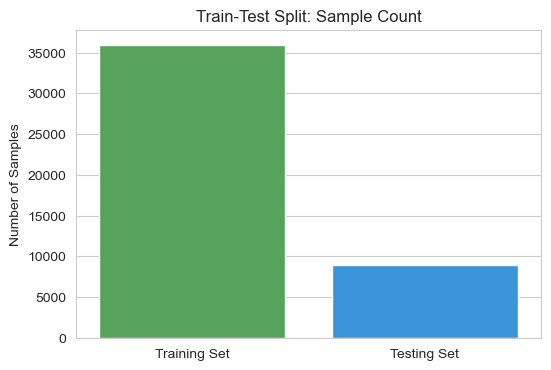

In [87]:
##Visual for training and testing sets
plt.figure(figsize=(6,4))
sns.barplot(
    x=['Training Set', 'Testing Set'], 
    y=[len(X_train), len(X_test)],
    palette=['#4CAF50', '#2196F3'] ##green and bluee
)

plt.ylabel("Number of Samples")
plt.title("Train-Test Split: Sample Count")
plt.show()

StandardScaler transforms features to have:
- Mean = 0
- Standard deviation = 1
This puts all features on the same scale for fair comparison.


In [88]:
# Initialize the scaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
# (Learn the mean and std from training data)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaling
# (Use the mean and std learned from training data)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("  All features now have mean ≈ 0 and standard deviation ≈ 1")

  All features now have mean ≈ 0 and standard deviation ≈ 1


Now I'll train three different machine learning models and compare them:

1. Logistic Regression - Simple, fast, interpretable baseline
2. Decision Tree - Tree-based model that creates rules
3. Random Forest - Ensemble of many decision trees

For each model:
- Train it on the training data
- Make predictions on the test data
- Evaluate its performance using multiple metrics

In [89]:
# Dictionary to store all model results
results = {}

print("Results storage initialized")

Results storage initialized


## Model 1: Logistic Regression

In [90]:
# Train Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Make predictions
log_reg_pred = log_reg.predict(X_test_scaled)

# Calculate metrics
log_reg_accuracy = accuracy_score(y_test, log_reg_pred)

# Store results
results['Logistic Regression'] = {
    'model': log_reg,
    'predictions': log_reg_pred,
    'accuracy': log_reg_accuracy
}

print(f"Logistic Regression: {log_reg_accuracy:.4f} accuracy")

Logistic Regression: 0.8487 accuracy


## Model 2: Decision Tree

In [91]:
# Train Decision Tree
decision_tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    class_weight='balanced',
    random_state=42
)
decision_tree.fit(X_train_scaled, y_train)

# Make predictions
dt_pred = decision_tree.predict(X_test_scaled)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, dt_pred)

# Store results
results['Decision Tree'] = {
    'model': decision_tree,
    'predictions': dt_pred,
    'accuracy': dt_accuracy
}

print(f"Decision Tree: {dt_accuracy:.4f} accuracy")

Decision Tree: 0.8888 accuracy


## Model 3: Random Forest

In [92]:
# Train Random Forest
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
random_forest.fit(X_train_scaled, y_train)

# Make predictions
rf_pred = random_forest.predict(X_test_scaled)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, rf_pred)

# Store results
results['Random Forest'] = {
    'model': random_forest,
    'predictions': rf_pred,
    'accuracy': rf_accuracy
}

print(f" Random Forest: {rf_accuracy:.4f} accuracy")

 Random Forest: 0.9192 accuracy


## Model Evaluation

In [93]:
comparison_data = []
for model_name in results.keys():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': results[model_name]['accuracy']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)

print("Model Performance Comparison:")
print(comparison_df.to_string(index=False))

Model Performance Comparison:
              Model  Accuracy
      Random Forest  0.919222
      Decision Tree  0.888778
Logistic Regression  0.848667


### Classification reports

In [94]:
# Print classification report for each model
for model_name in results.keys():
    predictions = results[model_name]['predictions']
    
    print(f"\n{model_name}:")
    print("-" * 60)
    print(classification_report(y_test, predictions, 
                                target_names=['Not Approved', 'Approved']))


Logistic Regression:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Approved       0.97      0.83      0.89      7000
    Approved       0.61      0.92      0.73      2000

    accuracy                           0.85      9000
   macro avg       0.79      0.87      0.81      9000
weighted avg       0.89      0.85      0.86      9000


Decision Tree:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Approved       0.97      0.89      0.93      7000
    Approved       0.69      0.90      0.78      2000

    accuracy                           0.89      9000
   macro avg       0.83      0.89      0.85      9000
weighted avg       0.91      0.89      0.89      9000


Random Forest:
------------------------------------------------------------
              precision    recall  f1-score   support

Not Approved       0.95      0.94      0.95      7000


Logistic Regression: decent baseline, good recall but lower precision for approved loans.


Decision Tree: better balance, captures more complex patterns, improved performance.


Random Forest: best overall results, highest accuracy, strongest precision and recall.


**Overall: Random Forest is the most reliable. with the highest accuracy**



### Confuison Matrix

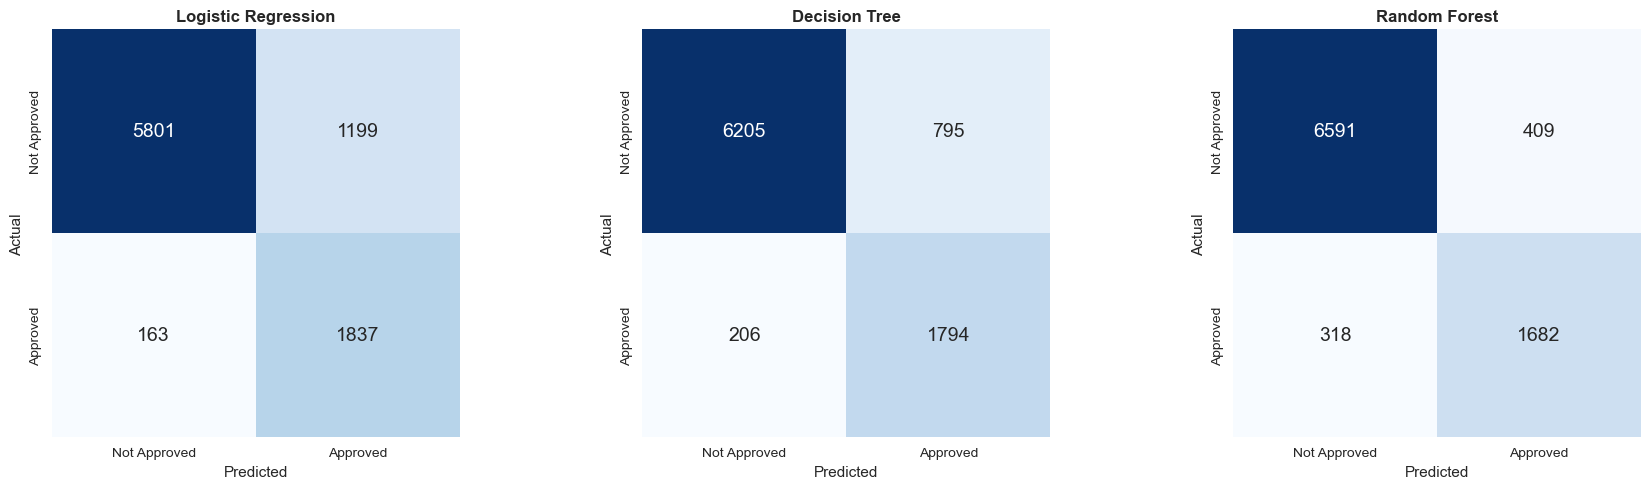

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(results.keys()):
    predictions = results[model_name]['predictions']
    cm = confusion_matrix(y_test, predictions)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                cbar=False, square=True, annot_kws={'size': 14})
    
    axes[idx].set_title(f'{model_name}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)
    axes[idx].set_xticklabels(['Not Approved', 'Approved'])
    axes[idx].set_yticklabels(['Not Approved', 'Approved'])

plt.tight_layout()
plt.show()

Across the confusion matrices, we can see a clear improvement as the models get more advanced. Logistic Regression performs reasonably well but makes more mistakes, especially by predicting “Approved” when the loan should be “Not Approved.” The Decision Tree reduces these errors and shows better balance between correct approvals and rejections. The Random Forest performs the best overall, with the fewest false positives and false negatives, meaning it is the most accurate and reliable at distinguishing between approved and not approved loans.

Top 10 Most Important Features:
                       Feature  Importance
previous_loan_defaults_on_file    0.383672
                 loan_int_rate    0.158605
           loan_percent_income    0.131411
                 person_income    0.105616
         person_home_ownership    0.058277
                     loan_amnt    0.041794
                  credit_score    0.034249
                   loan_intent    0.027522
                    person_age    0.016738
                person_emp_exp    0.015164


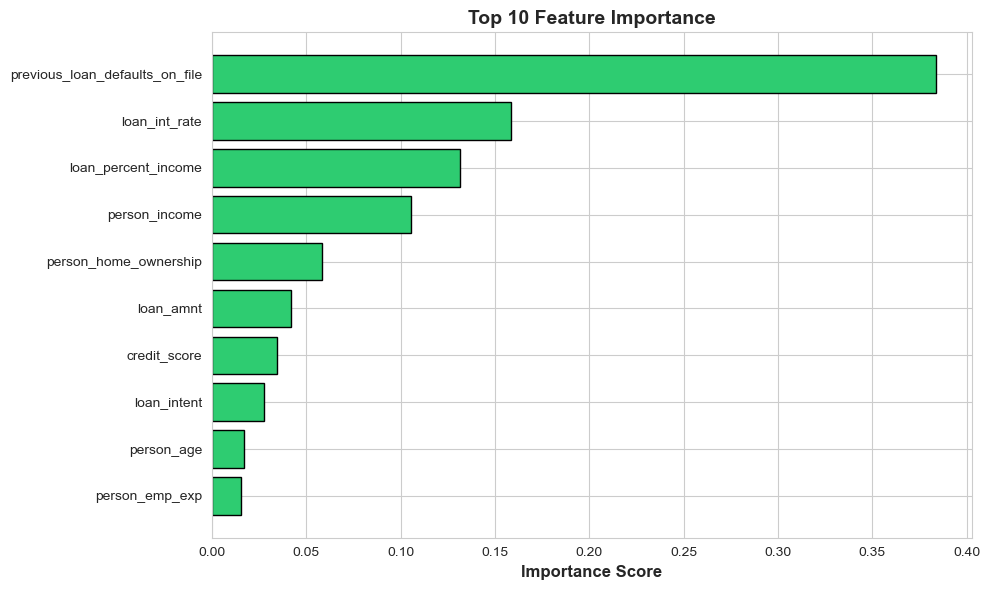

In [96]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))

top_10 = feature_importance.head(10)
plt.barh(range(len(top_10)), top_10['Importance'], color='#2ECC71', edgecolor='black')
plt.yticks(range(len(top_10)), top_10['Feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

The feature importance results show that previous loan defaults are by far the strongest predictor of loan approval, indicating that a borrower’s past repayment history carries the most weight. Interest rate, loan percent of income, and overall income are also highly influential, suggesting that affordability and financial stability play a major role in decision-making. Other factors like home ownership, loan amount, and credit score have some impact but are less dominant. Overall, the model relies most heavily on financial risk indicators and repayment history when predicting loan approval.

## Conclusion

In this project, I developed a loan approval prediction using machine-learning models while also examining how different applicant and loan factors can influence approval decicions. Through my Exploratory data analysis, I showed a strong class imbalance in the dataset, with the majority of applications not being approved. Then through visual exploration, I found meaningful patterns such as approval rates being consistent across gender and education levels, while home-ownership unexpected  behavior, with renters receiving higher approval rates than homeowners. Using Logistic Regression, Decision Tree, and Random Forest models, I observed a clear improvement in performance as the complxity of the model incresed. The Random Forest model delivered the strongest results, achieving the highest accuracy and the most balanced precision and recall, and its feature importance analysis highlighted previous loan defaults, interest rate, and loan-to-income percentage as the most influential predictors. Overall, this project demonstrates that machine learning can effectively support loan decision-making and that certain financial risk indicators play a more significant role than demographic attributes in predicting loan approval. 

## Refrences

Malviya, U. (n.d.). Bank Loan Data [Dataset]. Kaggle. https://www.kaggle.com/datasets/udaymalviya/bank-loan-data?resource=download

W3Schools. (n.d.). Python Machine Learning Train/Test. https://www.w3schools.com/python/python_ml_train_test.asp

W3Schools. (n.d.). Matplotlib – Intro to the Pyplot Module. https://www.w3schools.com/python/matplotlib_intro.asp

W3Schools. (n.d.). NumPy Random & Seaborn. https://www.w3schools.com/python/numpy/numpy_random_seaborn.asp